In [2]:
import sys, os

candidatos = [os.getcwd(), os.path.dirname(os.getcwd())]
project_root = None
for c in candidatos:
    if os.path.isdir(os.path.join(c, "src")):
        project_root = c
        break

if project_root is None:
    print("No encontré src/ en:", candidatos)
else:
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
    print("src/ encontrado en:", project_root)
import pickle
from src.scenarios import run_all_scenarios
from src.estimators import estimate_scenario

src/ encontrado en: c:\Users\wisda\OneDrive - ITESO\Documentos\ITESO\5 SEM\COMPORTAMIENTOS\PROYECTO 1\behavioral-finance


In [3]:
CACHE_PATH = "resultados_escenarios.pkl"

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        resultados, diagnosticos = pickle.load(f)
    print("Cargado de cache.")
else:
    resultados = run_all_scenarios(n_traders=1000, n_assets=50, n_days=500)
    diagnosticos = {sid: estimate_scenario(r, n_boot=1000, seed=1) for sid, r in resultados.items()}
    with open(CACHE_PATH, "wb") as f:
        pickle.dump((resultados, diagnosticos), f)
    print("Corrido y guardado en cache.")

Cargado de cache.


In [4]:
import pandas as pd

rows = []
for sid, diag in diagnosticos.items():
    pp = diag['pgr_plr']['point_estimate']
    pgr_ci = diag['pgr_plr']['PGR_ci']
    plr_ci = diag['pgr_plr']['PLR_ci']
    diff_ci = diag['pgr_plr']['PGR_minus_PLR_ci']
    reg = diag['regression']
    rows.append({
        'scenario_id': sid, 'nombre': diag['name'],
        'PGR': pp['PGR'], 'PGR_lo': pgr_ci[0], 'PGR_hi': pgr_ci[1],
        'PLR': pp['PLR'], 'PLR_lo': plr_ci[0], 'PLR_hi': plr_ci[1],
        'PGR_menos_PLR': pp['PGR_minus_PLR'], 'diff_lo': diff_ci[0], 'diff_hi': diff_ci[1],
        'slope_bruto': reg['gross']['slope'], 'p_bruto': reg['gross']['p_slope'],
        'slope_neto': reg['net']['slope'], 'p_neto': reg['net']['p_slope'],
        'slope_gap': reg['slope_gap'],
    })

resumen_df = pd.DataFrame(rows).set_index('scenario_id')
resumen_df.round(4)

,nombre,PGR,PGR_lo,PGR_hi,PLR,PLR_lo,PLR_hi,PGR_menos_PLR,diff_lo,diff_hi,slope_bruto,p_bruto,slope_neto,p_neto,slope_gap
scenario_id,,,,,,,,,,,,,,,
1,nulo,0.0702,0.0688,0.0717,0.0702,0.0682,0.0721,0.0000,-0.0021,0.0021,-0.0462,0.0000,-0.0477,0.0000,-0.0015
2,disposicion_baja,0.0815,0.0796,0.0834,0.0617,0.0604,0.0631,0.0198,0.0175,0.0220,-0.0535,0.0000,-0.0550,0.0000,-0.0014
3,disposicion_alta,0.1039,0.1021,0.1057,0.0111,0.0104,0.0119,0.0928,0.0909,0.0948,-0.1544,0.0000,-0.1560,0.0000,-0.0016
4,turnover_bajo,0.0726,0.0708,0.0745,0.0713,0.0700,0.0727,0.0013,-0.0008,0.0034,-0.0388,0.0003,-0.0401,0.0002,-0.0013
5,turnover_alto,0.0832,0.0816,0.0849,0.0761,0.0745,0.0777,0.0072,0.0051,0.0092,-0.1534,0.0000,-0.1548,0.0000,-0.0014
6,ambos_activos,0.0895,0.0879,0.0912,0.0440,0.0421,0.0458,0.0455,0.0429,0.0482,0.2703,0.0000,0.2683,0.0000,-0.0020
7,confound_rebalanceo,0.0969,0.0953,0.0986,0.0000,0.0000,0.0001,0.0969,0.0953,0.0986,0.2378,0.0000,0.2355,0.0000,-0.0023
8,confound_reversion_media,0.1044,0.1027,0.1065,0.0493,0.0479,0.0507,0.0552,0.0533,0.0572,0.0244,0.0293,0.0228,0.0410,-0.0016


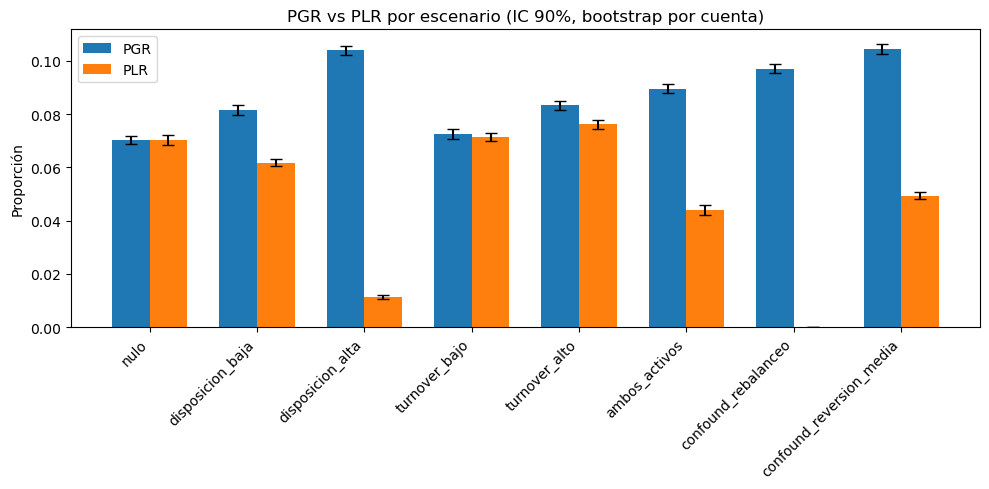

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 9)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
pgr_vals = resumen_df['PGR'].to_numpy()
pgr_err = np.vstack([pgr_vals - resumen_df['PGR_lo'].to_numpy(), resumen_df['PGR_hi'].to_numpy() - pgr_vals])
plr_vals = resumen_df['PLR'].to_numpy()
plr_err = np.vstack([plr_vals - resumen_df['PLR_lo'].to_numpy(), resumen_df['PLR_hi'].to_numpy() - plr_vals])
ax.bar(x - width/2, pgr_vals, width, yerr=pgr_err, label='PGR', capsize=4)
ax.bar(x + width/2, plr_vals, width, yerr=plr_err, label='PLR', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(resumen_df['nombre'], rotation=45, ha='right')
ax.set_ylabel('Proporción'); ax.set_title('PGR vs PLR por escenario (IC 90%, bootstrap por cuenta)')
ax.legend(); plt.tight_layout(); plt.show()

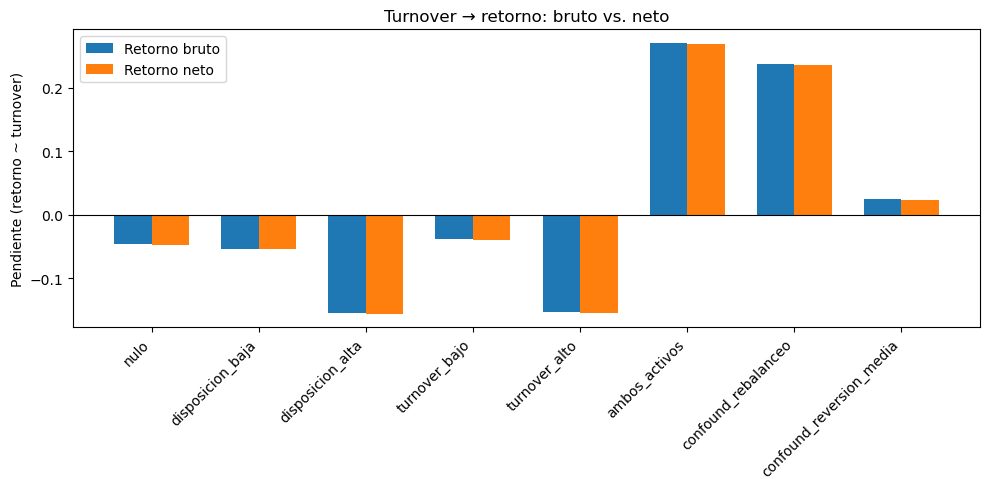

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, resumen_df['slope_bruto'].to_numpy(), width, label='Retorno bruto')
ax.bar(x + width/2, resumen_df['slope_neto'].to_numpy(), width, label='Retorno neto')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(resumen_df['nombre'], rotation=45, ha='right')
ax.set_ylabel('Pendiente (retorno ~ turnover)'); ax.set_title('Turnover → retorno: bruto vs. neto')
ax.legend(); plt.tight_layout(); plt.show()

In [7]:
from src.seeds import get_scenario_rngs
from src.market import simulate_market_factor
from src.scenarios import generate_scenario_traders, simulate_decisions_rebalancing, simulate_decisions_mean_reversion, SCENARIOS
from src.portfolio import initialize_portfolios
from src.estimators import compute_pgr_plr_events, compute_pgr_plr

def run_rebalancing_variant(rebalance_band, rebalance_interval=21, n_traders=1000, n_assets=50, n_days=500, base_seed=42):
    config = SCENARIOS[7]
    market_seed, traders_seed = get_scenario_rngs(7, base_seed=base_seed)
    trader_gen_seed, portfolio_seed, decision_seed = traders_seed.spawn(3)
    prices_df, betas = simulate_market_factor(n_assets=n_assets, n_days=n_days, seed=market_seed)
    traders_df = generate_scenario_traders(n_traders=n_traders, delta_range=config['delta_range'], kappa_range=config['kappa_range'], seed=trader_gen_seed)
    portfolios_df = initialize_portfolios(traders_df, prices_df, seed=portfolio_seed)
    positions_df = simulate_decisions_rebalancing(portfolios_df, traders_df, prices_df, rebalance_band=rebalance_band, rebalance_interval=rebalance_interval)
    return positions_df, prices_df

def run_mean_reversion_variant(mr_strength, mr_threshold=0.10, n_traders=1000, n_assets=50, n_days=500, base_seed=42):
    config = SCENARIOS[8]
    market_seed, traders_seed = get_scenario_rngs(8, base_seed=base_seed)
    trader_gen_seed, portfolio_seed, decision_seed = traders_seed.spawn(3)
    prices_df, betas = simulate_market_factor(n_assets=n_assets, n_days=n_days, seed=market_seed)
    traders_df = generate_scenario_traders(n_traders=n_traders, delta_range=config['delta_range'], kappa_range=config['kappa_range'], seed=trader_gen_seed)
    portfolios_df = initialize_portfolios(traders_df, prices_df, seed=portfolio_seed)
    positions_df = simulate_decisions_mean_reversion(portfolios_df, traders_df, prices_df, mr_strength=mr_strength, mr_threshold=mr_threshold, seed=decision_seed)
    return positions_df, prices_df

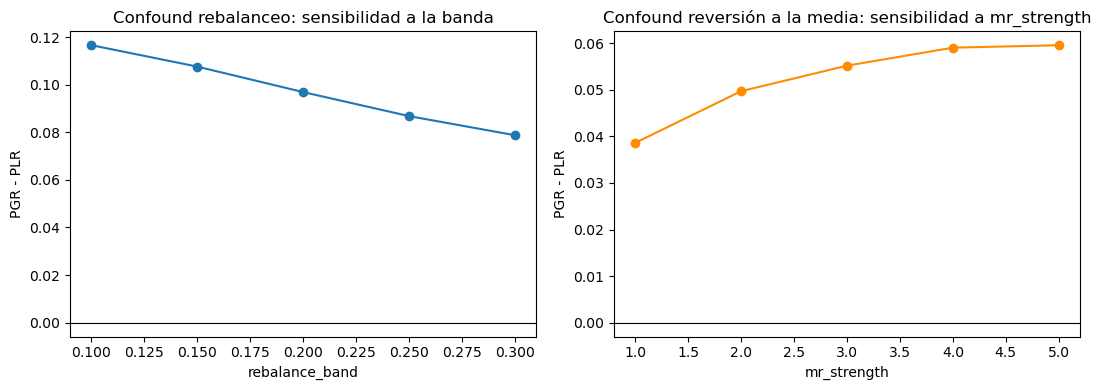

In [8]:
import matplotlib.pyplot as plt

bands = [0.10, 0.15, 0.20, 0.25, 0.30]
sens_reb = []
for band in bands:
    pos, prices = run_rebalancing_variant(rebalance_band=band)
    stats = compute_pgr_plr(compute_pgr_plr_events(pos, prices))
    sens_reb.append(stats['PGR_minus_PLR'])

strengths = [1.0, 2.0, 3.0, 4.0, 5.0]
sens_mr = []
for s in strengths:
    pos, prices = run_mean_reversion_variant(mr_strength=s)
    stats = compute_pgr_plr(compute_pgr_plr_events(pos, prices))
    sens_mr.append(stats['PGR_minus_PLR'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(bands, sens_reb, marker='o')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('rebalance_band'); axes[0].set_ylabel('PGR - PLR')
axes[0].set_title('Confound rebalanceo: sensibilidad a la banda')

axes[1].plot(strengths, sens_mr, marker='o', color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('mr_strength'); axes[1].set_ylabel('PGR - PLR')
axes[1].set_title('Confound reversión a la media: sensibilidad a mr_strength')

plt.tight_layout(); plt.show()

In [9]:
# Prueba de robustez: cada escenario se corre con varias semillas distintas
# (mundos simulados independientes) para confirmar que los resultados de la
# tabla principal no son un accidente de haber usado base_seed=42.
from src.scenarios import run_scenario
ALT_SEEDS = [42, 7, 123, 999, 2024]

robustez_rows = []
for sid, config in SCENARIOS.items():
    for seed in ALT_SEEDS:
        r = run_scenario(sid, n_traders=1000, n_assets=50, n_days=500, base_seed=seed)
        events = compute_pgr_plr_events(r['positions_df'], r['prices_df'])
        stats = compute_pgr_plr(events)
        robustez_rows.append({
            'scenario_id': sid, 'nombre': config['name'], 'seed': seed,
            'PGR_menos_PLR': stats['PGR_minus_PLR'],
        })

robustez_df = pd.DataFrame(robustez_rows)
robustez_pivot = robustez_df.pivot(index='nombre', columns='seed', values='PGR_menos_PLR')
robustez_pivot['promedio'] = robustez_pivot[ALT_SEEDS].mean(axis=1)
robustez_pivot['desv_std'] = robustez_pivot[ALT_SEEDS].std(axis=1)
robustez_pivot.round(4)

seed,7,42,123,999,2024,promedio,desv_std
nombre,,,,,,,
ambos_activos,0.0626,0.0455,0.0753,0.0627,0.0628,0.0618,0.0106
confound_rebalanceo,0.1439,0.0969,0.0909,0.1023,0.1513,0.1171,0.0283
confound_reversion_media,0.0624,0.0552,0.0599,0.0693,0.0882,0.0670,0.0129
disposicion_alta,0.0898,0.0928,0.0875,0.1115,0.0739,0.0911,0.0135
disposicion_baja,0.0248,0.0198,0.0128,0.0235,0.0258,0.0214,0.0053
nulo,-0.0077,0.0000,-0.0162,0.0041,-0.0020,-0.0043,0.0079
turnover_alto,0.0124,0.0072,0.0140,-0.0081,0.0084,0.0068,0.0088
turnover_bajo,-0.0020,0.0013,0.0070,0.0006,-0.0185,-0.0023,0.0096


In [10]:
from src.scenarios import SCENARIOS, run_scenario
from src.estimators import compute_trader_returns, estimate_overconfidence_regression

rows_slope = []
for sid, config in SCENARIOS.items():
    for seed in ALT_SEEDS:
        r = run_scenario(sid, n_traders=1000, n_assets=50, n_days=500, base_seed=seed)
        trader_stats = compute_trader_returns(
            r['portfolios_df'], r['positions_df'], r['traders_df'], r['prices_df']
        )
        reg = estimate_overconfidence_regression(trader_stats)
        rows_slope.append({
            'scenario_id': sid, 'nombre': config['name'], 'seed': seed,
            'slope_bruto': reg['gross']['slope'],
        })

robustez_slope_df = pd.DataFrame(rows_slope)
pivot_slope = robustez_slope_df.pivot(index='nombre', columns='seed', values='slope_bruto')
pivot_slope['promedio'] = pivot_slope[ALT_SEEDS].mean(axis=1)
pivot_slope['desv_std'] = pivot_slope[ALT_SEEDS].std(axis=1)
pivot_slope['signo_consistente'] = pivot_slope[ALT_SEEDS].apply(
    lambda fila: (fila > 0).all() or (fila < 0).all(), axis=1
)
print(pivot_slope.round(4).to_string())

n_consistentes = pivot_slope['signo_consistente'].sum()
print(f"\n{n_consistentes} de 8 escenarios mantienen el signo de la pendiente entre semillas.")

seed                           7      42     123     999    2024  promedio  desv_std  signo_consistente
nombre                                                                                                 
ambos_activos             0.0156  0.2703 -0.0591  0.0630 -0.4142   -0.0249    0.2496              False
confound_rebalanceo       0.0291  0.2378 -0.4473 -0.1315  0.1448   -0.0334    0.2693              False
confound_reversion_media  0.2437  0.0244  0.1840  0.1123  0.1277    0.1384    0.0821               True
disposicion_alta          0.1513 -0.1544  0.1731  0.0353  0.2601    0.0931    0.1599              False
disposicion_baja         -0.4154 -0.0535 -0.0680 -0.0816 -0.2422   -0.1722    0.1559               True
nulo                      0.0766 -0.0462  0.0153 -0.1915 -0.0473   -0.0386    0.0996              False
turnover_alto            -0.2483 -0.1534 -0.0010  0.1049 -0.1427   -0.0881    0.1394              False
turnover_bajo            -0.2460 -0.0388 -0.1401 -0.0666  0.0190

"La pendiente turnover-retorno solo mantiene su signo entre semillas en los escenarios 2 y 8; en los otros 6, el valor reportado en la tabla principal depende del camino de mercado simulado y no debe interpretarse como una relación estructural. El PGR-PLR, en cambio, es robusto en 7 de 8 escenarios."

In [11]:
# Verificaciones automáticas contra lo que el diseño predice.
# Si alguna de estas falla, algo está mal en el simulador o en PGR/PLR.

assert abs(resumen_df.loc[1, 'PGR_menos_PLR']) < 0.01, "el escenario nulo debería dar ~0"
assert resumen_df.loc[3, 'PGR_menos_PLR'] > resumen_df.loc[2, 'PGR_menos_PLR'], \
    "disposición alta debería superar a disposición baja"
assert resumen_df.loc[7, 'PGR_menos_PLR'] > 0.05, "el confound de rebalanceo debe mostrar falso positivo"
assert resumen_df.loc[8, 'PGR_menos_PLR'] > 0.05, "el confound de reversión a la media debe mostrar falso positivo"

print("Todas las verificaciones pasaron.")

Todas las verificaciones pasaron.
